In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import joblib

In [13]:
train_cats = r"C:\Users\mrpar\PRODIGY_ML_TASKS\PRODIGY_ML_03\train\Cat"
train_dogs = r"C:\Users\mrpar\PRODIGY_ML_TASKS\PRODIGY_ML_03\train\Dog"

test_cats = r"C:\Users\mrpar\PRODIGY_ML_TASKS\PRODIGY_ML_03\test1\Cat"
test_dogs = r"C:\Users\mrpar\PRODIGY_ML_TASKS\PRODIGY_ML_03\test1\Dog"

IMG_SIZE = 64

In [14]:
def extract_features(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    image = image.flatten()

    return image

In [15]:
X_train = []
y_train = []

# Cats
for file in os.listdir(train_cats)[:1500]:

    path = os.path.join(train_cats, file)

    features = extract_features(path)

    if features is not None:
        X_train.append(features)
        y_train.append(0)

# Dogs
for file in os.listdir(train_dogs)[:1500]:

    path = os.path.join(train_dogs, file)

    features = extract_features(path)

    if features is not None:
        X_train.append(features)
        y_train.append(1)

print("Training Images:", len(X_train))

Training Images: 3000


In [16]:
X_test = []
y_test = []

# Cats
for file in os.listdir(test_cats)[:500]:

    path = os.path.join(test_cats, file)

    features = extract_features(path)

    if features is not None:
        X_test.append(features)
        y_test.append(0)

# Dogs
for file in os.listdir(test_dogs)[:500]:

    path = os.path.join(test_dogs, file)

    features = extract_features(path)

    if features is not None:
        X_test.append(features)
        y_test.append(1)

print("Testing Images:", len(X_test))

Testing Images: 1000


In [17]:
X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

print(X_train.shape)
print(X_test.shape)

(3000, 4096)
(1000, 4096)


In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
model = LinearSVC(
    max_iter=5000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

In [22]:
y_pred = model.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 51.40%


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.57      0.54       500
           1       0.52      0.46      0.49       500

    accuracy                           0.51      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.51      0.51      0.51      1000



In [25]:
joblib.dump(model, "cat_dog_svm.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [26]:
image_path = r"C:\Users\mrpar\PRODIGY_ML_TASKS\PRODIGY_ML_03\Domestic-cat-32.jpg"

features = extract_features(image_path)

features = scaler.transform([features])

prediction = model.predict(features)[0]

label = "Dog" if prediction == 1 else "Cat"

print("Prediction:", label)

Prediction: Dog


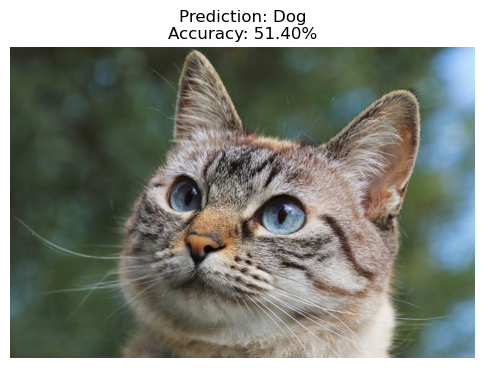

In [27]:
image_path = r"C:\Users\mrpar\PRODIGY_ML_TASKS\PRODIGY_ML_03\Domestic-cat-32.jpg"

img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

features = extract_features(image_path)

features = scaler.transform([features])

prediction = model.predict(features)[0]

label = "Dog" if prediction == 1 else "Cat"

plt.figure(figsize=(6,6))

plt.imshow(img_rgb)

plt.title(
    f"Prediction: {label}\nAccuracy: {accuracy*100:.2f}%"
)

plt.axis("off")

plt.show()